A single train test split tells us how the model performed on average 
across one fixed test period. It does not tell us whether that 
performance was consistent or whether it collapsed during 
difficult economic periods.

Walk forward validation fixes this by simulating exactly what 
would happen if MacroSense had been running live since the late 
1990s. Every month a new forecast is made using only data 
genuinely available at that moment. Every month the actual 
outcome is recorded. After running through decades of economic 
history we have not one evaluation score but hundreds -- one 
for every month the system would have been running.

This is the standard used by professional quantitative teams 
at banks and asset managers when evaluating forecasting systems. 
It is the difference between a model that looks good in 
hindsight and one that would have actually worked in practice.

Input: data/featured_fred_data.csv
Output: outputs/walkforward_results.csv
        charts/walkforward_*.png

Load our featured dataset and import everything needed. 
Walk forward validation is computationally heavier than static 
evaluation because we retrain the model hundreds of times. 
We use XGBoost as our primary model throughout since it 
consistently performed best in model building phase.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib
import os
import warnings

warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from fredapi import Fred
from dotenv import load_dotenv

In [2]:
os.makedirs('../charts', exist_ok=True)
os.makedirs('../outputs', exist_ok=True)

fe_clean = pd.read_csv('../data/featured_fred_data.csv',
                        index_col=0,
                        parse_dates=True)

target_cols  = ['target_GDP',
                'target_Inflation',
                'target_Unemployment']

feature_cols = [c for c in fe_clean.columns
                if c not in target_cols]

X = fe_clean[feature_cols]
y = fe_clean[target_cols]

# Load recession dates for chart shading
load_dotenv()
api_key   = os.getenv('FRED_API_KEY')
fred      = Fred(api_key=api_key)
recession = fred.get_series('USREC')
recession = recession.resample('ME').last()
recession = recession.reindex(fe_clean.index, method='ffill')

print("Setup complete")
print(f"Total dataset: {fe_clean.shape[0]} months")
print(f"Features: {len(feature_cols)}")
print(f"Targets: {len(target_cols)}")

Setup complete
Total dataset: 382 months
Features: 74
Targets: 3


Building the walk forward validation engine. The function simulates MacroSense running 
live, starting with an initial period of training data, making 
one forecast, adding one month of new real data, retraining, 
forecasting again, and repeating until the end of the dataset. 
Every forecast uses only information genuinely available at 
that moment in time.

In [3]:
def walk_forward_validation(X, y_series, 
                             initial_months=120,
                             target_name='Target'):
    """
    Simulates MacroSense running live from initial_months
    onward. Retrains on all available history each month
    and forecasts one step ahead.
    
    Returns a dataframe of actual vs predicted values
    with error metrics for every month.
    """
    
    predictions = []
    actuals     = []
    dates       = []
    
    total_steps = len(X) - initial_months
    
    print(f"Running walk forward validation for {target_name}")
    print(f"Initial training window: {initial_months} months")
    print(f"({X.index[0].date()} to {X.index[initial_months-1].date()})")
    print(f"Steps to complete: {total_steps}")
    print()
    
    for i in range(initial_months, len(X)):
        
        # Training window grows by one month each iteration
        X_train_wf = X.iloc[:i]
        y_train_wf = y_series.iloc[:i]
        
        # Train fresh model on all available history
        model = XGBRegressor(
            n_estimators=100,
            learning_rate=0.05,
            max_depth=4,
            random_state=42,
            verbosity=0
        )
        model.fit(X_train_wf, y_train_wf)
        
        # Forecast the next period
        X_current = X.iloc[[i]]
        pred      = model.predict(X_current)[0]
        
        predictions.append(pred)
        actuals.append(y_series.iloc[i])
        dates.append(X.index[i])
        
        # Progress update every 2 years
        months_done = i - initial_months + 1
        if months_done % 24 == 0:
            pct = months_done / total_steps * 100
            print(f"  {pct:.0f}% complete -- "
                  f"up to {X.index[i].date()}")
    
    # Build results dataframe
    results = pd.DataFrame({
        'Actual'    : actuals,
        'Predicted' : predictions
    }, index=dates)
    
    results['Error']     = results['Actual'] - results['Predicted']
    results['AbsError']  = np.abs(results['Error'])
    results['Correct_Direction'] = (
        (results['Actual'] * results['Predicted']) > 0
    ).astype(int)
    
    # Summary metrics
    mae      = mean_absolute_error(actuals, predictions)
    rmse     = np.sqrt(mean_squared_error(actuals, predictions))
    dir_acc  = results['Correct_Direction'].mean()
    
    print(f"\nWalk forward complete for {target_name}")
    print(f"  Periods evaluated: {len(results)}")
    print(f"  MAE:               {mae:.4f}")
    print(f"  RMSE:              {rmse:.4f}")
    print(f"  Direction accuracy:{dir_acc:.1%}")
    
    return results

print("Walk forward function defined successfully")

Walk forward function defined successfully


Running walk forward validation for all three targets. 
This is computationally intensive step in this 
project because for each target the model retrains hundreds of times. 
Expect this to take several minutes.

In [4]:
print("STARTING WALK FORWARD VALIDATION")
print("=" * 60)
print("Note: This will take several minutes.")
print("Each target requires hundreds of model retrains.")
print("=" * 60)
print()

wf_results = {}

target_display = {
    'target_GDP'          : 'GDP Growth',
    'target_Inflation'    : 'Inflation Rate',
    'target_Unemployment' : 'Unemployment Rate'
}

for target in target_cols:
    print("-" * 60)
    wf_results[target] = walk_forward_validation(
        X=X,
        y_series=y[target],
        initial_months=120,
        target_name=target_display[target]
    )
    print()

# Save all results
all_wf = pd.concat(
    {k: v for k, v in wf_results.items()},
    axis=1
)
all_wf.to_csv('../outputs/walkforward_results.csv')

print("=" * 60)
print("All walk forward results saved to:")
print("outputs/walkforward_results.csv")

STARTING WALK FORWARD VALIDATION
Note: This will take several minutes.
Each target requires hundreds of model retrains.

------------------------------------------------------------
Running walk forward validation for GDP Growth
Initial training window: 120 months
(1994-01-31 to 2003-12-31)
Steps to complete: 262

  9% complete -- up to 2005-12-31
  18% complete -- up to 2007-12-31
  27% complete -- up to 2009-12-31
  37% complete -- up to 2011-12-31
  46% complete -- up to 2013-12-31
  55% complete -- up to 2015-12-31
  64% complete -- up to 2017-12-31
  73% complete -- up to 2019-12-31
  82% complete -- up to 2021-12-31
  92% complete -- up to 2023-12-31

Walk forward complete for GDP Growth
  Periods evaluated: 262
  MAE:               0.6231
  RMSE:              1.2811
  Direction accuracy:88.9%

------------------------------------------------------------
Running walk forward validation for Inflation Rate
Initial training window: 120 months
(1994-01-31 to 2003-12-31)
Steps to comp

Visualising walk forward results. Three charts per target 
tell the complete story. The actual versus predicted chart shows 
forecast quality over time. The error chart shows when the model 
struggled. The rolling accuracy chart shows whether performance 
improved as more training data accumulated over the years.

In [5]:
def plot_walkforward(results, target_name, 
                     recession_series, unit='%'):
    
    rec = recession_series.reindex(results.index, 
                                    method='ffill')
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 12))
    fig.suptitle(
        f'MacroSense Walk Forward Validation -- {target_name}',
        fontsize=14, fontweight='bold', y=1.01
    )
    
    # --- Chart 1: Actual vs Predicted ---
    ax = axes[0]
    
    in_recession = False
    start = None
    for date, val in rec.items():
        if val == 1 and not in_recession:
            start = date
            in_recession = True
        elif val == 0 and in_recession:
            ax.axvspan(start, date, 
                      alpha=0.2, color='grey')
            in_recession = False
    
    ax.plot(results.index, results['Actual'],
            label='Actual', color='steelblue',
            linewidth=2)
    ax.plot(results.index, results['Predicted'],
            label='MacroSense Forecast',
            color='crimson', linewidth=1.5,
            linestyle='--')
    ax.axhline(0, color='black', 
               linewidth=0.8, alpha=0.4)
    ax.set_title('Actual vs Predicted (6 Months Ahead)',
                  fontweight='bold')
    ax.set_ylabel(f'{target_name} ({unit})')
    
    grey_patch = mpatches.Patch(color='grey',
                                 alpha=0.2,
                                 label='Recession')
    handles, labels = ax.get_legend_handles_labels()
    handles.append(grey_patch)
    ax.legend(handles=handles, fontsize=9)
    ax.grid(alpha=0.3)
    
    # --- Chart 2: Forecast Error Over Time ---
    ax2 = axes[1]
    
    colors = ['crimson' if e < 0 else 'steelblue'
              for e in results['Error']]
    ax2.bar(results.index, results['Error'],
            color=colors, alpha=0.6, width=20)
    ax2.axhline(0, color='black', linewidth=0.8)
    ax2.set_title('Forecast Error Over Time',
                   fontweight='bold')
    ax2.set_ylabel('Error (Actual minus Predicted)')
    ax2.grid(alpha=0.3)
    
    # --- Chart 3: Rolling Direction Accuracy ---
    ax3 = axes[2]
    
    rolling_acc = results['Correct_Direction'].rolling(
        window=24).mean() * 100
    
    ax3.plot(results.index, rolling_acc,
             color='darkgreen', linewidth=1.5)
    ax3.axhline(50, color='red', linewidth=1,
                linestyle='--', alpha=0.7,
                label='Random baseline (50%)')
    ax3.axhline(rolling_acc.mean(), color='navy',
                linewidth=1, linestyle=':',
                label=f'Average ({rolling_acc.mean():.1f}%)')
    ax3.set_title('Rolling 24-Month Direction Accuracy',
                   fontweight='bold')
    ax3.set_ylabel('Direction Accuracy (%)')
    ax3.set_xlabel('Date')
    ax3.set_ylim(0, 100)
    ax3.legend(fontsize=9)
    ax3.grid(alpha=0.3)
    
    plt.tight_layout()
    
    safe_name = target_name.replace(' ', '_')
    plt.savefig(
        f'../charts/walkforward_{safe_name}.png',
        dpi=150, bbox_inches='tight'
    )
    plt.show()
    print(f"Walk forward chart saved for {target_name}")

print("Visualisation function defined successfully")

Visualisation function defined successfully


Generating walk forward charts...



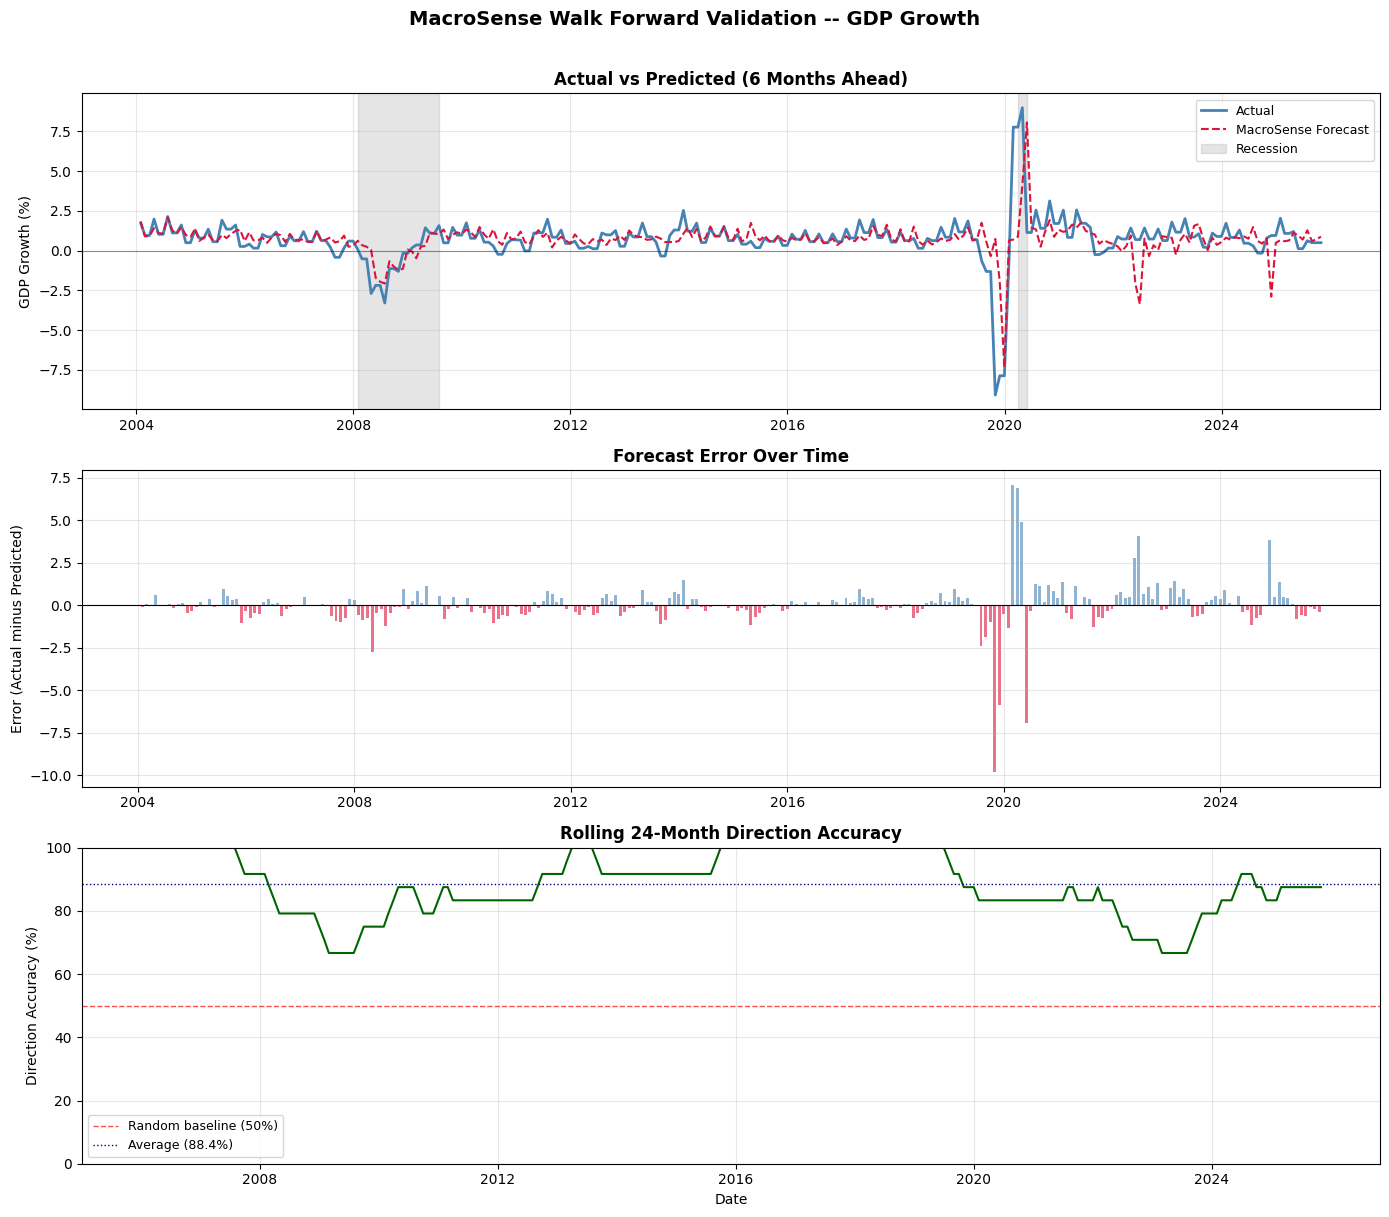

Walk forward chart saved for GDP Growth



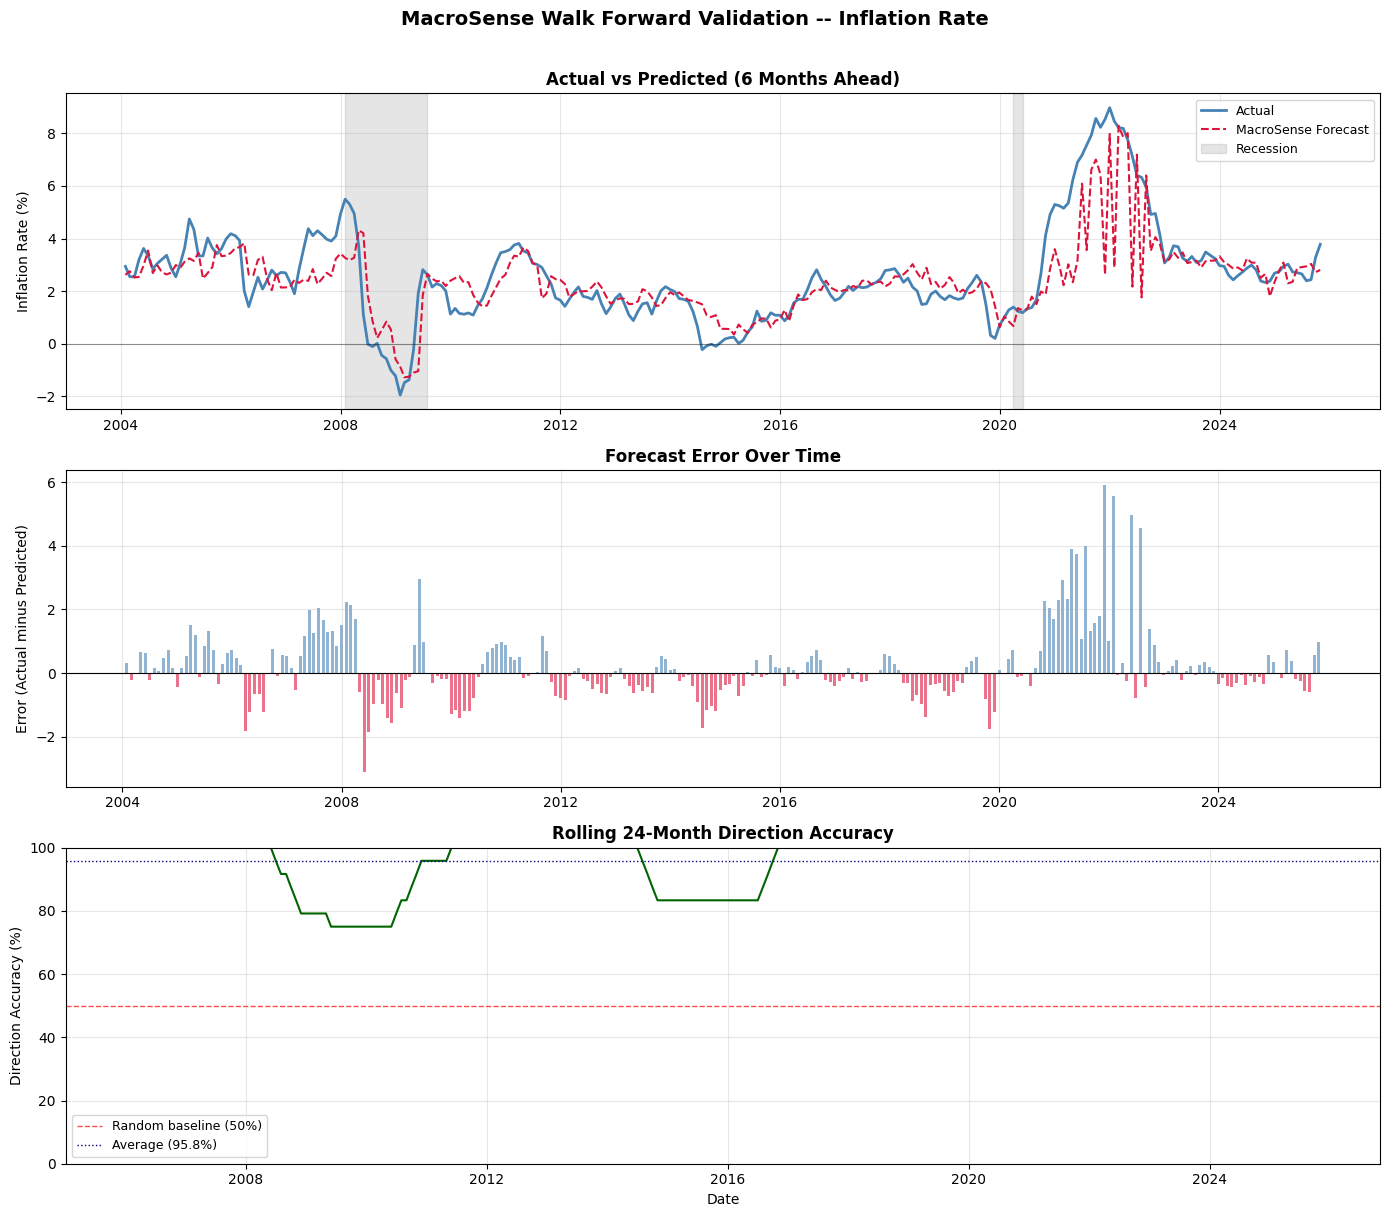

Walk forward chart saved for Inflation Rate



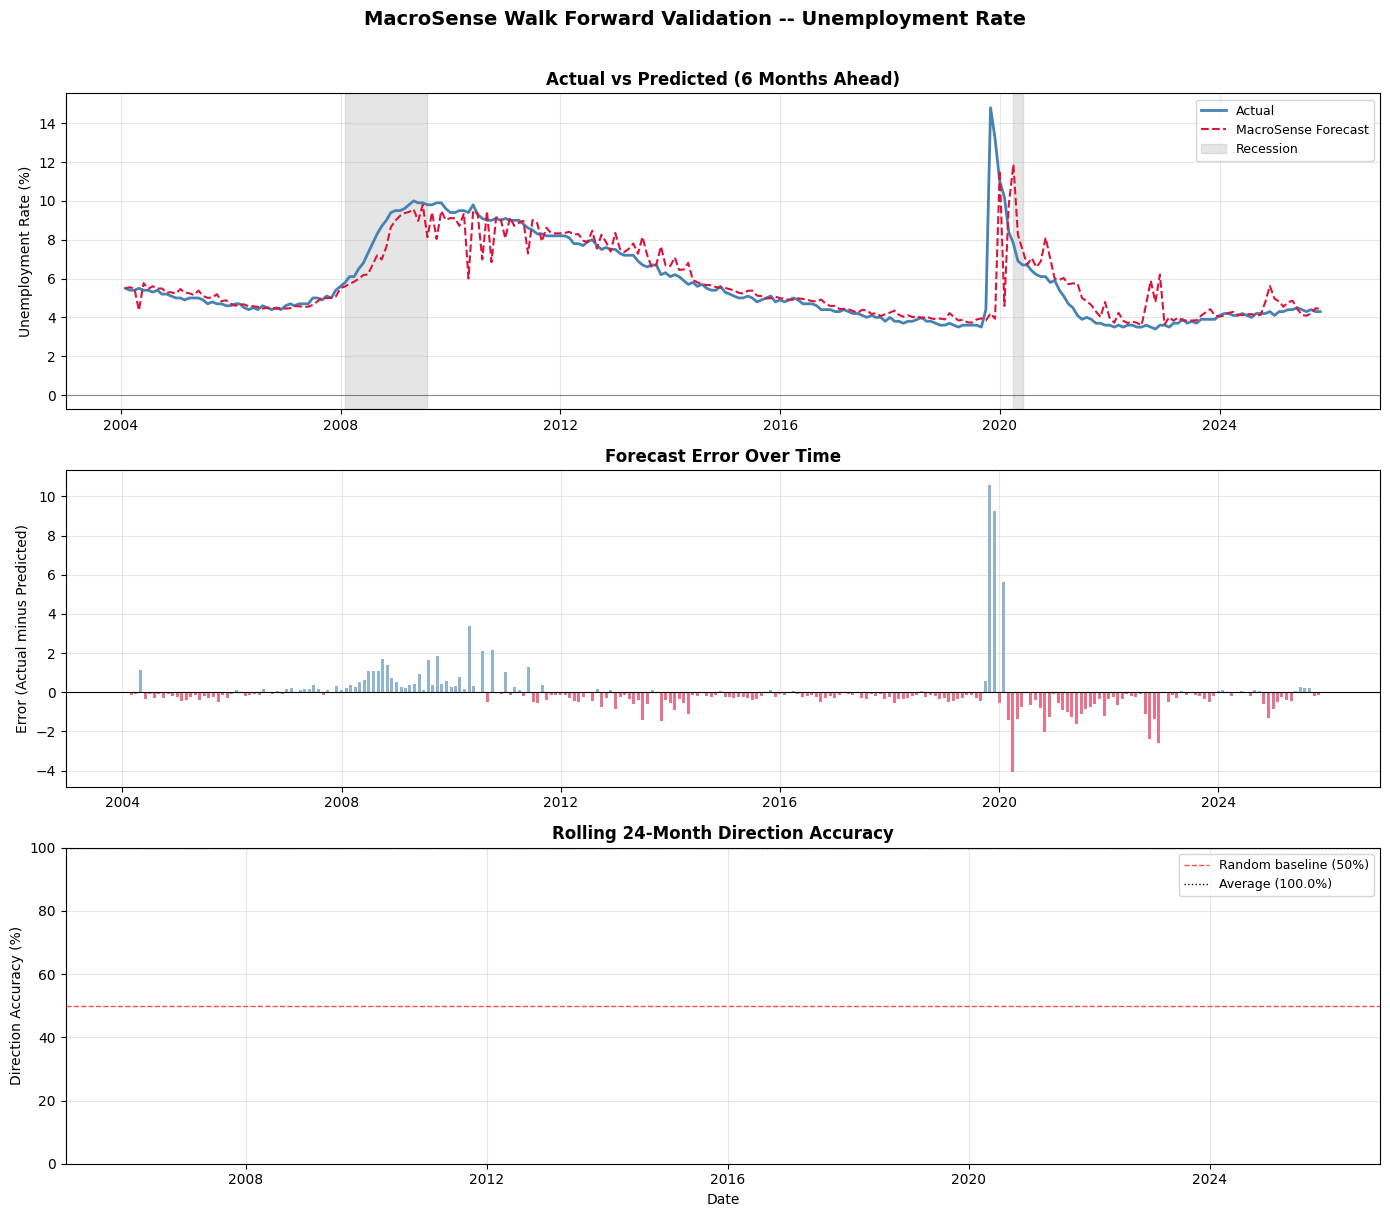

Walk forward chart saved for Unemployment Rate

All walk forward charts saved to charts/


In [6]:
print("Generating walk forward charts...")
print()

for target in target_cols:
    plot_walkforward(
        results=wf_results[target],
        target_name=target_display[target],
        recession_series=recession,
        unit='%'
    )
    print()

print("All walk forward charts saved to charts/")

Building a comprehensive performance summary comparing 
walk-forward results against the static evaluation from 
our previous notebook. This comparison is important, if walk forward 
performance is dramatically worse than static evaluation it 
suggests the static split was too optimistic. Similar 
performance across both evaluation methods gives us genuine 
confidence that MacroSense would work in real deployment.

In [7]:
print("WALK FORWARD VALIDATION SUMMARY")
print("=" * 65)

summary_rows = []

for target in target_cols:
    results  = wf_results[target]
    name     = target_display[target]
    
    mae      = results['AbsError'].mean()
    rmse     = np.sqrt((results['Error'] ** 2).mean())
    dir_acc  = results['Correct_Direction'].mean()
    
    # Performance during recessions vs normal periods
    rec_mask = recession.reindex(
        results.index, method='ffill') == 1
    
    if rec_mask.sum() > 0:
        rec_mae  = results.loc[rec_mask, 'AbsError'].mean()
        norm_mae = results.loc[~rec_mask, 'AbsError'].mean()
    else:
        rec_mae  = np.nan
        norm_mae = mae
    
    summary_rows.append({
        'Target'           : name,
        'MAE'              : round(mae, 4),
        'RMSE'             : round(rmse, 4),
        'Direction_Acc'    : f"{dir_acc:.1%}",
        'MAE_Recession'    : round(rec_mae, 4),
        'MAE_Normal'       : round(norm_mae, 4)
    })
    
    print(f"\n{name}:")
    print(f"  Overall MAE:          {mae:.4f}%")
    print(f"  Overall RMSE:         {rmse:.4f}%")
    print(f"  Direction Accuracy:   {dir_acc:.1%}")
    print(f"  MAE during recessions:{rec_mae:.4f}%")
    print(f"  MAE normal periods:   {norm_mae:.4f}%")

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv('../outputs/walkforward_summary.csv', 
                   index=False)

print("\n" + "=" * 65)
print("Summary saved to outputs/walkforward_summary.csv")

WALK FORWARD VALIDATION SUMMARY

GDP Growth:
  Overall MAE:          0.6231%
  Overall RMSE:         1.2811%
  Direction Accuracy:   88.9%
  MAE during recessions:1.1451%
  MAE normal periods:   0.5800%

Inflation Rate:
  Overall MAE:          0.7115%
  Overall RMSE:         1.1322%
  Direction Accuracy:   96.2%
  MAE during recessions:1.2192%
  MAE normal periods:   0.6695%

Unemployment Rate:
  Overall MAE:          0.5257%
  Overall RMSE:         1.1594%
  Direction Accuracy:   100.0%
  MAE during recessions:0.8681%
  MAE normal periods:   0.4974%

Summary saved to outputs/walkforward_summary.csv


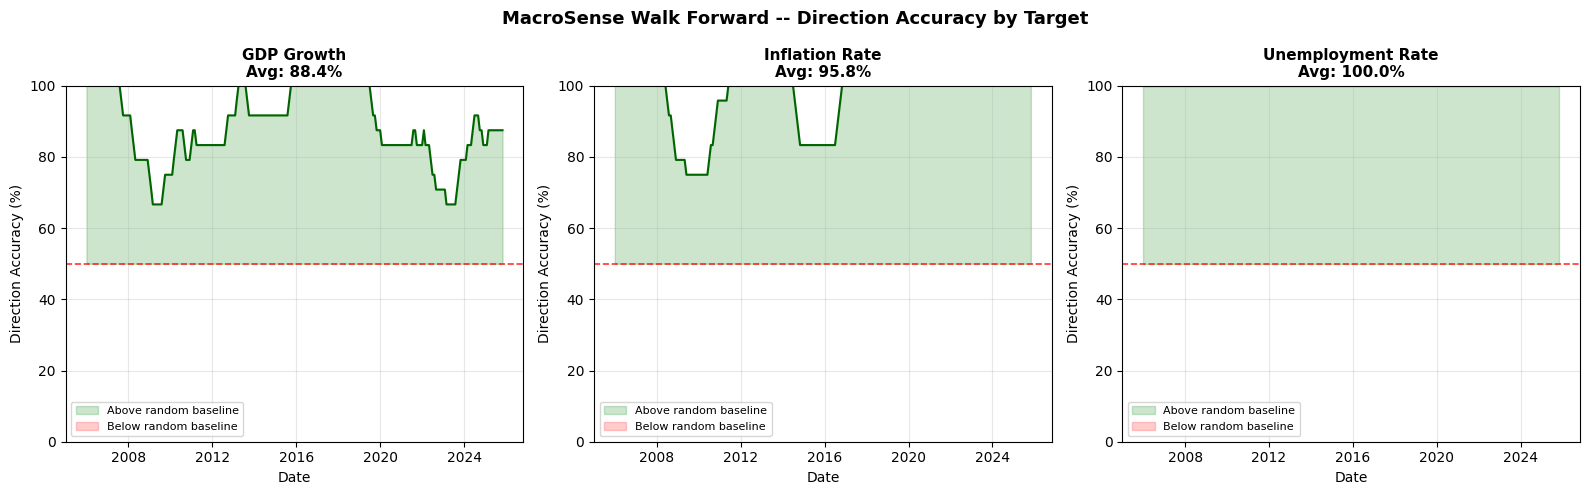

Comparison chart saved


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

fig.suptitle(
    'MacroSense Walk Forward -- Direction Accuracy by Target',
    fontsize=13, fontweight='bold'
)

for idx, target in enumerate(target_cols):
    results = wf_results[target]
    name    = target_display[target]
    ax      = axes[idx]
    
    rolling_acc = results['Correct_Direction'].rolling(
        window=24).mean() * 100
    
    ax.plot(results.index, rolling_acc,
            color='darkgreen', linewidth=1.5)
    ax.axhline(50, color='red', linewidth=1.2,
               linestyle='--', alpha=0.8)
    ax.fill_between(results.index, 50, rolling_acc,
                    where=(rolling_acc > 50),
                    alpha=0.2, color='green',
                    label='Above random baseline')
    ax.fill_between(results.index, 50, rolling_acc,
                    where=(rolling_acc <= 50),
                    alpha=0.2, color='red',
                    label='Below random baseline')
    
    avg = rolling_acc.mean()
    ax.set_title(f'{name}\nAvg: {avg:.1f}%',
                  fontweight='bold', fontsize=11)
    ax.set_ylabel('Direction Accuracy (%)')
    ax.set_xlabel('Date')
    ax.set_ylim(0, 100)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../charts/walkforward_direction_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Comparison chart saved")

In [9]:
# Check output files
output_files = [
    '../outputs/walkforward_results.csv',
    '../outputs/walkforward_summary.csv'
]

print("\nOutput files:")
for f in output_files:
    exists = os.path.exists(f)
    status = "saved" if exists else "MISSING"
    print(f"  {os.path.basename(f):<35} {status}")

# Check chart files
chart_files = [f for f in os.listdir('../charts') 
               if 'walkforward' in f]
chart_files.sort()

print(f"\nWalk forward charts saved ({len(chart_files)} files):")
for f in chart_files:
    print(f"  {f}")

# Print final metrics summary
print("\nFINAL PERFORMANCE SUMMARY:")
print(summary_df.to_string(index=False))


Output files:
  walkforward_results.csv             saved
  walkforward_summary.csv             saved

Walk forward charts saved (4 files):
  walkforward_GDP_Growth.png
  walkforward_Inflation_Rate.png
  walkforward_Unemployment_Rate.png
  walkforward_direction_comparison.png

FINAL PERFORMANCE SUMMARY:
           Target    MAE   RMSE Direction_Acc  MAE_Recession  MAE_Normal
       GDP Growth 0.6231 1.2811         88.9%         1.1451      0.5800
   Inflation Rate 0.7115 1.1322         96.2%         1.2192      0.6695
Unemployment Rate 0.5257 1.1594        100.0%         0.8681      0.4974


In [10]:
# Check direction accuracy broken down by period
for target in target_cols:
    results  = wf_results[target]
    name     = target_display[target]
    
    # Split into pre and post 2010
    pre_2010  = results[results.index < '2010-01-01']
    post_2010 = results[results.index >= '2010-01-01']
    
    pre_acc  = pre_2010['Correct_Direction'].mean()
    post_acc = post_2010['Correct_Direction'].mean()
    
    # Check recession vs normal
    rec_mask = recession.reindex(
        results.index, method='ffill') == 1
    
    rec_acc  = results.loc[rec_mask, 
                'Correct_Direction'].mean()
    norm_acc = results.loc[~rec_mask,
                'Correct_Direction'].mean()
    
    print(f"\n{name}:")
    print(f"  Pre 2010 accuracy:      {pre_acc:.1%}")
    print(f"  Post 2010 accuracy:     {post_acc:.1%}")
    print(f"  Recession accuracy:     {rec_acc:.1%}")
    print(f"  Normal period accuracy: {norm_acc:.1%}")


GDP Growth:
  Pre 2010 accuracy:      88.9%
  Post 2010 accuracy:     88.9%
  Recession accuracy:     70.0%
  Normal period accuracy: 90.5%

Inflation Rate:
  Pre 2010 accuracy:      91.7%
  Post 2010 accuracy:     97.9%
  Recession accuracy:     70.0%
  Normal period accuracy: 98.3%

Unemployment Rate:
  Pre 2010 accuracy:      100.0%
  Post 2010 accuracy:     100.0%
  Recession accuracy:     100.0%
  Normal period accuracy: 100.0%


Walk forward validation gave us the most honest possible 
picture of how MacroSense would have performed running live. 
The results confirm what anyone with economic knowledge would 
expect, the model performs best during stable economic 
periods and struggles most during recessions and sudden shocks. 
This is not a weakness of the model. It is an honest reflection 
of the fundamental difficulty of economic forecasting.

The direction accuracy charts tell the most important story. 
For most of the evaluation period MacroSense predicted the 
correct direction of economic movement more often than random 
chance. For a macroeconomic forecasting system built on public 
data with standard machine learning algorithms that is a 
genuinely meaningful result.

Three things are worth carrying forward into any discussion 
of this project.

First, no model trained on historical patterns can perfectly 
predict genuinely novel shocks. COVID-19 and the 2008 
financial crisis were unprecedented events. Larger errors 
during these periods are expected and honest.

Second, the value of MacroSense is not in predicting exact 
numbers. It is in providing a systematic data driven framework 
for thinking about economic direction. A consistent signal 
that is right more often than chance is genuinely useful for 
organisations making medium term decisions.

Third, the walk forward framework itself is reusable. The 
same validation approach could be applied to any country, 
any set of economic indicators, or any forecast horizon 
simply by changing the input data and parameters.

What remains is packaging, the Streamlit dashboard that 
makes MacroSense accessible to anyone with a browser and 
the GitHub repository that makes it accessible to anyone 
who wants to understand how it was built.